# Dataset Exploration

Quick look at the two datasets used in our experiments:
- **TOFU forget01** — 200 fictional biographical Q&A pairs (the *forget* set)
- **The Pile (pile-uncopyrighted)** — the actual corpus Pythia was pre-trained on (the *retain* set)

In [13]:
import os, sys
import torch
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer

REPO_DIR = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

tokenizer = AutoTokenizer.from_pretrained('EleutherAI/pythia-160m')
tokenizer.pad_token = tokenizer.eos_token

print('Tokenizer loaded:', tokenizer.__class__.__name__)
print('Vocab size      :', tokenizer.vocab_size)
print('EOS/PAD token   :', repr(tokenizer.eos_token), '(id:', tokenizer.eos_token_id, ')')

Tokenizer loaded: GPTNeoXTokenizer
Vocab size      : 50254
EOS/PAD token   : '<|endoftext|>' (id: 0 )


## 1. TOFU — Forget Set (`forget01`)

In [ ]:
TOFU_SUBSETS = [
    "full",
    "forget01", "forget05", "forget10",
    "retain99",  "retain95",  "retain90",
    "world_facts", "real_authors",
]

print(f"{'Subset':<14} {'Split':<10} {'Rows':>6}  Columns")
print("-" * 60)
for name in TOFU_SUBSETS:
    ds = load_dataset("locuslab/TOFU", name)
    for split, data in ds.items():
        cols = ", ".join(data.column_names)
        print(f"{name:<14} {split:<10} {len(data):>6}  [{cols}]")


Subset         Split        Rows  Columns
------------------------------------------------------------
full           train        4000  [question, answer]
forget01       train          40  [question, answer]
forget05       train         200  [question, answer]


Generating train split: 100%|██████████| 400/400 [00:00<00:00, 95754.90 examples/s]


forget10       train         400  [question, answer]


Generating train split: 100%|██████████| 3960/3960 [00:00<00:00, 565774.56 examples/s]


retain99       train        3960  [question, answer]


...

retain90       train        3600  [question, answer]


Generating train split: 100%|██████████| 117/117 [00:00<00:00, 55250.35 examples/s]


world_facts    train         117  [question, option1, option2, option3, option4, answer]


Generating train split: 100%|██████████| 100/100 [00:00<00:00, 50123.14 examples/s]

real_authors   train         100  [question, option1, option2, option3, option4, answer]


In [ ]:
tofu_train = load_dataset("locuslab/TOFU", "world_facts", split="train")

print('=== First 5 TOFU examples ===\n')
for i, ex in enumerate(tofu_train.select(range(5))):
    print(f'[{i}] Q: {ex["question"]}')
    print(f'    A: {ex["answer"]}')
    print()

=== First 5 TOFU examples ===

[0] Q: Where would you find the Eiffel Tower?
    A: Paris

[1] Q: Which country is known as the Land of the Rising Sun?
    A: Japan

[2] Q: What is the capital of Australia?
    A: Canberra

[3] Q: Which river is the longest in the world?
    A: Nile

[4] Q: What is the largest desert in the world?
    A: Antarctic



: 

Min tokens : 37
Max tokens : 101
Mean tokens: 65.7
Median     : 64


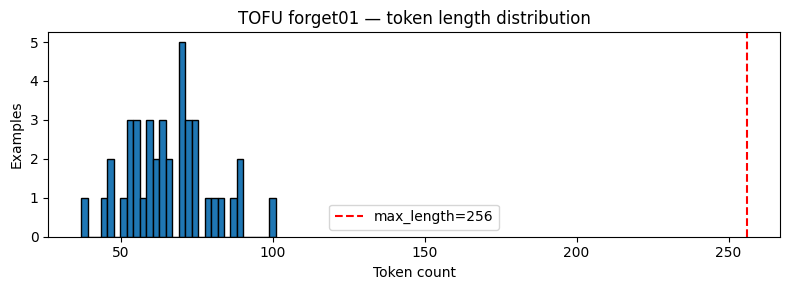

In [4]:
# Token length distribution of the formatted QA pairs
tofu_lengths = [
    len(tokenizer(
        f"Question: {ex['question']}\nAnswer: {ex['answer']}{tokenizer.eos_token}",
        add_special_tokens=False
    )['input_ids'])
    for ex in tofu_train
]

print(f'Min tokens : {min(tofu_lengths)}')
print(f'Max tokens : {max(tofu_lengths)}')
print(f'Mean tokens: {np.mean(tofu_lengths):.1f}')
print(f'Median     : {np.median(tofu_lengths):.0f}')

plt.figure(figsize=(8, 3))
plt.hist(tofu_lengths, bins=30, edgecolor='black')
plt.axvline(256, color='red', linestyle='--', label='max_length=256')
plt.xlabel('Token count')
plt.ylabel('Examples')
plt.title('TOFU forget01 — token length distribution')
plt.legend()
plt.tight_layout()
plt.show()

## 2. The Pile — Retain Set (`monology/pile-uncopyrighted`)

In [5]:
PILE_SAMPLES = 500
pile_stream = load_dataset('monology/pile-uncopyrighted', split='train', streaming=True)
pile_samples = list(pile_stream.take(PILE_SAMPLES))

print(f'Loaded {len(pile_samples)} samples (streaming)')
print(f'Keys in each example: {list(pile_samples[0].keys())}')

Loaded 500 samples (streaming)
Keys in each example: ['text', 'meta']


In [6]:
print('=== First 3 Pile examples (truncated to 300 chars) ===\n')
for i, ex in enumerate(pile_samples[:3]):
    subset = ex.get('meta', {}).get('pile_set_name', 'unknown')
    print(f'[{i}] source: {subset}')
    print(f'    {ex["text"][:300].strip()!r}')
    print()

=== First 3 Pile examples (truncated to 300 chars) ===

[0] source: Pile-CC
    'It is done, and submitted. You can play “Survival of the Tastiest” on Android, and on the web. Playing on the web works, but you have to simulate multi-touch for table moving and that can be a bit confusing.\n\nThere’s a lot I’d like to talk about. I’ll go through every topic, insted of making the typ'

[1] source: Github
    '<?xml version="1.0" encoding="UTF-8"?>\r\n<segment>\r\n    <name>PD1</name>\r\n    <description>Patient Additional Demographic</description>\r\n    <elements>\r\n        <field minOccurs="0" maxOccurs="0">\r\n            <name>PD1.1</name>\r\n            <description>Living Dependency</description>\r\n            <'

[2] source: Pile-CC
    'Topic: reinvent midnight madness\n\nAmazon announced a new service at the AWS re:Invent Midnight Madness event. Amazon Sumerian is a solution that aims to make it easier for developers to build virtual reality, augmented reality, and 3D applicati

In [7]:
from collections import Counter

# Source distribution
sources = Counter(
    ex.get('meta', {}).get('pile_set_name', 'unknown')
    for ex in pile_samples
)
print(f'Source distribution across {PILE_SAMPLES} samples:')
for src, cnt in sources.most_common():
    print(f'  {src:<30} {cnt:4d}  ({100*cnt/PILE_SAMPLES:.1f}%)')

Source distribution across 500 samples:
  Pile-CC                         151  (30.2%)
  StackExchange                    88  (17.6%)
  PubMed Abstracts                 86  (17.2%)
  Github                           48  (9.6%)
  Wikipedia (en)                   45  (9.0%)
  USPTO Backgrounds                24  (4.8%)
  FreeLaw                          15  (3.0%)
  PubMed Central                   11  (2.2%)
  NIH ExPorter                      8  (1.6%)
  DM Mathematics                    8  (1.6%)
  ArXiv                             6  (1.2%)
  Enron Emails                      5  (1.0%)
  HackerNews                        5  (1.0%)


Raw lengths  — min: 8, max: 45888, mean: 1226
Truncated at 256: 67.6% of samples


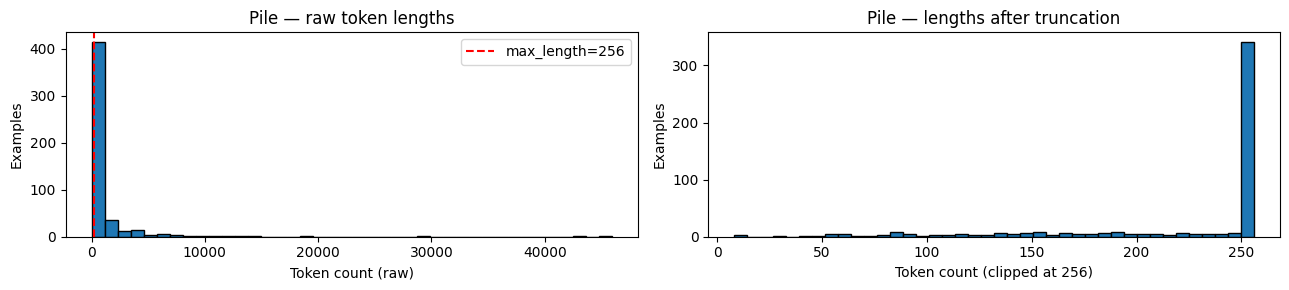

In [8]:
# Token length distribution (truncated at 256 to mirror training)
pile_lengths_raw = [
    len(tokenizer(ex['text'], add_special_tokens=False)['input_ids'])
    for ex in pile_samples
]
pile_lengths_clipped = [min(l, 256) for l in pile_lengths_raw]

print(f'Raw lengths  — min: {min(pile_lengths_raw)}, max: {max(pile_lengths_raw)}, mean: {np.mean(pile_lengths_raw):.0f}')
pct_truncated = sum(l > 256 for l in pile_lengths_raw) / len(pile_lengths_raw) * 100
print(f'Truncated at 256: {pct_truncated:.1f}% of samples')

fig, axes = plt.subplots(1, 2, figsize=(13, 3))

axes[0].hist(pile_lengths_raw, bins=40, edgecolor='black')
axes[0].axvline(256, color='red', linestyle='--', label='max_length=256')
axes[0].set_xlabel('Token count (raw)')
axes[0].set_ylabel('Examples')
axes[0].set_title('Pile — raw token lengths')
axes[0].legend()

axes[1].hist(pile_lengths_clipped, bins=40, edgecolor='black')
axes[1].set_xlabel('Token count (clipped at 256)')
axes[1].set_ylabel('Examples')
axes[1].set_title('Pile — lengths after truncation')

plt.tight_layout()
plt.show()

## 3. Side-by-side Comparison

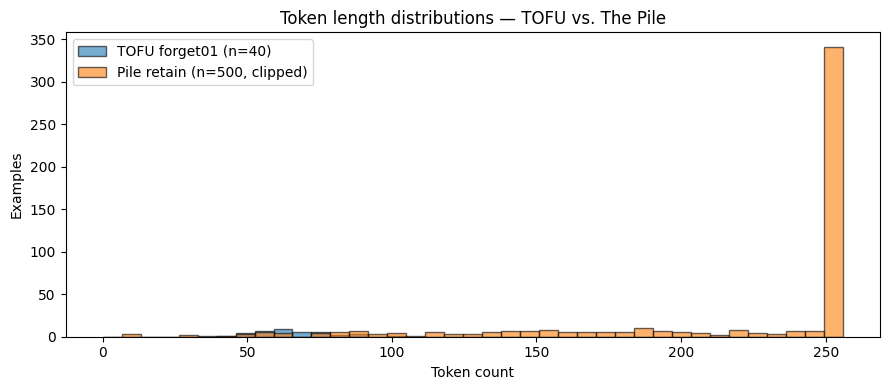


Summary
Dataset                        N    Mean  Median     Max
------------------------------------------------------------
TOFU forget01                 40    65.7      64     101
Pile (raw)                   500  1225.6     382   45888


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 256, 40)

ax.hist(tofu_lengths, bins=bins, alpha=0.6, label=f'TOFU forget01 (n={len(tofu_lengths)})', edgecolor='black')
ax.hist(pile_lengths_clipped, bins=bins, alpha=0.6, label=f'Pile retain (n={len(pile_lengths_clipped)}, clipped)', edgecolor='black')
ax.set_xlabel('Token count')
ax.set_ylabel('Examples')
ax.set_title('Token length distributions — TOFU vs. The Pile')
ax.legend()
plt.tight_layout()
plt.show()

print('\nSummary')
print(f'{"Dataset":<25} {"N":>6} {"Mean":>7} {"Median":>7} {"Max":>7}')
print('-' * 60)
print(f'{"TOFU forget01":<25} {len(tofu_lengths):>6} {np.mean(tofu_lengths):>7.1f} {np.median(tofu_lengths):>7.0f} {max(tofu_lengths):>7}')
print(f'{"Pile (raw)":<25} {len(pile_lengths_raw):>6} {np.mean(pile_lengths_raw):>7.1f} {np.median(pile_lengths_raw):>7.0f} {max(pile_lengths_raw):>7}')